# 阿马特里切 DPM-RNN 扩展版本

本代码在原始RNN基础上增加了三种分析模式：

1. **模式0 (Original RNN)**: 原始的RNN时间序列预测方法，使用logit变换和概率预测
2. **模式1 (Simple Statistical)**: 不进行时间序列预测，直接计算震前相干性的均值和标准差，然后计算z-score
3. **模式2 (Direct Coherence)**: 不进行logit变换，使用RNN直接预测相干性值，score=(前一个时间相干性-后一个时间相干性)/(前一个时间相干性+后一个时间相干性)

用户可以通过设置 `ANALYSIS_MODE` 参数来选择分析模式。

In [31]:
# ============================================================
# 阿马特里切 DPM-RNN 扩展版本
# ============================================================
# 新增功能:
#   模式0: 原始RNN预测 (logit变换 + 概率预测)
#   模式1: 简单统计方法 (直接计算均值和标准差)
#   模式2: 直接相干性预测 (无logit变换 + 差分score)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import os
from tqdm import tqdm
import warnings
import gc
from pathlib import Path
import psutil
from datetime import datetime

warnings.filterwarnings('ignore')

# 设置随机种子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("=" * 70)
print("阿马特里切DPM-RNN扩展版本 - 多模式分析")
print("=" * 70)
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
print()
print("可用分析模式:")
print("  模式0: 原始RNN预测 (logit变换 + 概率预测)")
print("  模式1: 简单统计方法 (直接计算均值和标准差)")
print("  模式2: 直接相干性预测 (无logit变换 + 差分score)")

阿马特里切DPM-RNN扩展版本 - 多模式分析
PyTorch版本: 2.4.1
CUDA可用: True

可用分析模式:
  模式0: 原始RNN预测 (logit变换 + 概率预测)
  模式1: 简单统计方法 (直接计算均值和标准差)
  模式2: 直接相干性预测 (无logit变换 + 差分score)


In [32]:
# ============================================================
# 用户配置区域 - 选择分析模式
# ============================================================

# 分析模式选择:
#   0 = 原始RNN预测 (logit变换 + 概率预测)
#   1 = 简单统计方法 (直接计算均值和标准差)
#   2 = 直接相干性预测 (无logit变换 + 差分score)

ANALYSIS_MODE = 2  # <-- 修改此值以选择不同的分析模式

# 数据路径配置
DATA_PATH = '/scratch/yangyanchen/amatrice2025/RNN/length12/adjacent_coherence_timeseries_last13.npy'

# 事件时间索引 (同震数据的索引位置)
EVENT_INDEX = 12

print(f"\n当前选择的分析模式: {ANALYSIS_MODE}")
if ANALYSIS_MODE == 0:
    print("模式描述: 原始RNN预测 (logit变换 + 概率预测)")
elif ANALYSIS_MODE == 1:
    print("模式描述: 简单统计方法 (直接计算均值和标准差)")
elif ANALYSIS_MODE == 2:
    print("模式描述: 直接相干性预测 (无logit变换 + 差分score)")
else:
    print("警告: 未知的分析模式，将使用默认模式0")
    ANALYSIS_MODE = 0


当前选择的分析模式: 2
模式描述: 直接相干性预测 (无logit变换 + 差分score)


In [33]:
# ============================================================
# 工具函数
# ============================================================

def check_memory_usage():
    """检查内存使用情况"""
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    memory_gb = memory_info.rss / 1024 / 1024 / 1024
    print(f"当前内存使用: {memory_gb:.2f} GB")
    
    if torch.cuda.is_available():
        gpu_memory = torch.cuda.memory_allocated() / 1024**3
        print(f"GPU内存使用: {gpu_memory:.2f} GB")
    
    return memory_gb

In [34]:
# ============================================================
# 数据处理类
# ============================================================

class AmatriceCoherenceTimeseries:
    """阿马特里切相干时间序列处理类 - 扩展版本"""
    
    def __init__(self, file_path, event_index=14, transform='logit_squared', mode=0):
        """
        初始化相干性时间序列
        
        Parameters:
        -----------
        file_path : str
            数据文件路径
        event_index : int
            事件发生时间索引
        transform : str
            数据变换类型 ('logit_squared', 'logit', 'none')
        mode : int
            分析模式 (0, 1, 2)
        """
        self.file_path = file_path
        self.event_index = event_index
        self.transform = transform
        self.mode = mode
        
        # 根据模式调整变换类型
        if mode == 2:  # 直接相干性模式不使用logit变换
            self.transform = 'none'
            print("模式2: 已禁用logit变换")
        
        print(f"加载阿马特里切数据: {file_path}")
        
        # 加载原始数据
        self.data = self._load_data()
        print(f"数据形状: {self.data.shape}")
        
        # 设置参数
        self.length = self.data.shape[0]
        self.shape = self.data.shape[1:]  # (height, width)
        
        print(f"时间序列长度: {self.length}")
        print(f"事件发生索引: {self.event_index}")
        print(f"空间尺寸: {self.shape}")
        print(f"总像素数: {np.prod(self.shape):,}")
        print(f"数据变换类型: {self.transform}")
        
        # 数据验证
        self._validate_data()
        check_memory_usage()
    
    def _load_data(self):
        """加载相干性数据"""
        try:
            data = np.load(self.file_path).astype(np.float32)
            print(f"成功加载数据，形状: {data.shape}, 数据类型: {data.dtype}")
            
            # 检查数据有效性
            valid_mask = np.isfinite(data)
            valid_ratio = np.mean(valid_mask)
            print(f"有效数据比例: {valid_ratio:.3f}")
            
            # 检查数据范围
            valid_data = data[valid_mask]
            if len(valid_data) > 0:
                print(f"数据范围: [{np.min(valid_data):.6f}, {np.max(valid_data):.6f}]")
            
            return data
        except Exception as e:
            print(f"加载数据失败: {e}")
            raise
    
    def _validate_data(self):
        """验证和清理数据"""
        print("验证和清理数据...")
        
        # 处理无效值
        for t in range(self.data.shape[0]):
            frame = self.data[t]
            invalid_mask = ~np.isfinite(frame)
            if np.any(invalid_mask):
                invalid_count = np.sum(invalid_mask)
                print(f"时间步 {t}: {invalid_count:,} 个无效像素")
                
                # 使用中位数填充
                valid_data = frame[np.isfinite(frame)]
                if len(valid_data) > 0:
                    fill_value = np.median(valid_data)
                    frame[invalid_mask] = fill_value
                else:
                    frame[invalid_mask] = 0.5
                
                self.data[t] = frame
        
        # 确保相干性在合理范围内
        self.data = np.clip(self.data, 1e-6, 1-1e-6)
        print("数据验证完成")
    
    def apply_transform(self, data):
        """应用数据变换"""
        if self.transform == 'logit_squared':
            return np.log(data**2 / (1 - data**2))
        elif self.transform == 'logit':
            return np.log(data / (1 - data))
        else:  # 'none'
            return data
    
    def get_training_data(self):
        """获取预震训练数据"""
        training_data = self.data[:self.event_index]  # 使用所有预震数据
        
        print("应用数据变换...")
        transformed_data = np.array([self.apply_transform(frame) for frame in training_data])
        
        print(f"训练数据形状: {transformed_data.shape}")
        return transformed_data
    
    def get_raw_training_data(self):
        """获取未变换的预震数据（用于模式1和模式2）"""
        return self.data[:self.event_index].copy()
    
    def get_coseismic_data(self):
        """获取同震数据"""
        if self.event_index < len(self.data):
            coseismic_data = self.data[self.event_index]
            return self.apply_transform(coseismic_data)
        return None
    
    def get_raw_coseismic_data(self):
        """获取未变换的同震数据（用于模式1和模式2）"""
        if self.event_index < len(self.data):
            return self.data[self.event_index].copy()
        return None
    
    def get_pre_event_last(self):
        """获取震前最后一个时间点的相干性数据（用于模式2）"""
        if self.event_index > 0:
            return self.data[self.event_index - 1].copy()
        return None

In [35]:
# ============================================================
# 数据集类
# ============================================================

class OriginalPixelDataset(Dataset):
    """
    原始逻辑的像素数据集
    每个样本是一个像素的完整预震时间序列
    """
    
    def __init__(self, coherence_ts, pixel_subsample_rate=0.1, use_transform=True):
        """
        初始化数据集
        
        Parameters:
        -----------
        coherence_ts : AmatriceCoherenceTimeseries
            相干性时间序列对象
        pixel_subsample_rate : float
            像素子采样率
        use_transform : bool
            是否使用数据变换
        """
        self.coherence_ts = coherence_ts
        self.use_transform = use_transform
        
        # 获取预震数据
        if use_transform:
            self.data = coherence_ts.get_training_data()  # 变换后的数据
        else:
            self.data = coherence_ts.get_raw_training_data()  # 原始数据
        
        self.time_length, self.height, self.width = self.data.shape
        
        # 随机选择训练像素
        total_pixels = self.height * self.width
        num_pixels_sample = int(total_pixels * pixel_subsample_rate)
        self.pixel_indices = np.random.choice(total_pixels, size=num_pixels_sample, replace=False)
        
        print(f"像素数据集创建:")
        print(f"  - 预震时间长度: {self.time_length}")
        print(f"  - 训练像素数量: {len(self.pixel_indices):,} / {total_pixels:,}")
        print(f"  - 每个样本长度: {self.time_length} (完整预震序列)")
        print(f"  - 使用数据变换: {use_transform}")
    
    def __len__(self):
        return len(self.pixel_indices)
    
    def __getitem__(self, idx):
        # 获取像素索引
        pixel_idx = self.pixel_indices[idx]
        y_idx = pixel_idx // self.width
        x_idx = pixel_idx % self.width
        
        # 提取该像素的完整预震时间序列
        pixel_timeseries = self.data[:, y_idx, x_idx]  # (time_length,)
        
        return torch.FloatTensor(pixel_timeseries)

In [36]:
# ============================================================
# 模型定义
# ============================================================

class OptimizedRNNModel(nn.Module):
    """优化超参数的RNN模型架构"""
    
    def __init__(self, config):
        super(OptimizedRNNModel, self).__init__()
        self.config = config
        
        # 模型参数
        self.data_dim = config['data_dim']
        self.rnn_dim = config['rnn_dim']
        self.h_dim = config['h_dim']
        self.num_layers = config['num_layers']
        self.rnn_cell = config['rnn_cell']
        self.dropout_rate = config['dropout_rate']
        self.mode = config.get('mode', 0)  # 分析模式
        
        # 解码器（添加BatchNorm和Dropout）
        self.dec_fc = nn.Sequential(
            nn.Linear(self.rnn_dim, self.h_dim),
            nn.BatchNorm1d(self.h_dim),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate),
            
            nn.Linear(self.h_dim, self.h_dim),
            nn.BatchNorm1d(self.h_dim),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate),
            
            nn.Linear(self.h_dim, self.h_dim),
            nn.BatchNorm1d(self.h_dim),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate)
        )
        
        # 输出层
        if self.mode == 2:
            # 模式2: 直接预测相干性值（单一输出）
            self.dec_mean = nn.Sequential(
                nn.Linear(self.h_dim, self.data_dim),
                nn.Sigmoid()  # 确保输出在0-1范围内
            )
            self.dec_logvar = None  # 模式2不需要方差预测
        else:
            # 模式0: 原始概率预测（均值和对数方差）
            self.dec_mean = nn.Linear(self.h_dim, self.data_dim)
            self.dec_logvar = nn.Linear(self.h_dim, self.data_dim)
        
        # RNN层
        if self.rnn_cell == 'gru':
            self.rnn = nn.GRU(
                self.data_dim, self.rnn_dim, self.num_layers, 
                batch_first=False, dropout=self.dropout_rate if self.num_layers > 1 else 0
            )
        elif self.rnn_cell == 'lstm':
            self.rnn = nn.LSTM(
                self.data_dim, self.rnn_dim, self.num_layers, 
                batch_first=False, dropout=self.dropout_rate if self.num_layers > 1 else 0
            )
        else:
            raise NotImplementedError(f"RNN cell type {self.rnn_cell} not implemented")
        
        # 权重初始化
        self._initialize_weights()
        
        print(f"RNN模型创建:")
        print(f"  - 分析模式: {self.mode}")
        print(f"  - RNN类型: {self.rnn_cell.upper()}")
        print(f"  - RNN维度: {self.rnn_dim}")
        print(f"  - RNN层数: {self.num_layers}")
        print(f"  - 解码器维度: {self.h_dim}")
        print(f"  - Dropout率: {self.dropout_rate}")
        print(f"  - 参数数量: {self.count_parameters():,}")
    
    def _initialize_weights(self):
        """权重初始化"""
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                if 'rnn' in name:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.kaiming_uniform_(param, nonlinearity='relu')
            elif 'bias' in name:
                nn.init.zeros_(param)
            elif 'weight' in name and param.dim() == 1:
                nn.init.ones_(param)
    
    def count_parameters(self):
        """计算参数数量"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def forward(self, batch, generate_dmp=False):
        """
        前向传播
        
        Parameters:
        -----------
        batch : torch.Tensor
            输入数据 (batch_size, time_length)
        generate_dmp : bool
            是否为损害图生成模式
        
        Returns:
        --------
        如果是模式2: 返回 (pred_value, None)
        如果是模式0: 返回 (pred_mean, pred_logvar)
        """
        # 添加特征维度
        if len(batch.shape) == 2:
            batch = batch.unsqueeze(-1)
        
        # 转换为RNN期望的格式
        batch = batch.transpose(0, 1)
        seq_len, batch_size, data_dim = batch.size()
        
        # 初始化隐藏状态
        if self.rnn_cell == 'gru':
            h_0 = torch.zeros(self.num_layers, batch_size, self.rnn_dim).to(batch.device)
            self.rnn.flatten_parameters()
            hiddens, _ = self.rnn(batch, h_0)
        elif self.rnn_cell == 'lstm':
            h_0 = torch.zeros(self.num_layers, batch_size, self.rnn_dim).to(batch.device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.rnn_dim).to(batch.device)
            self.rnn.flatten_parameters()
            hiddens, _ = self.rnn(batch, (h_0, c_0))
        
        # 处理隐藏状态
        if not generate_dmp:
            hiddens = torch.cat([h_0[-1,:,:].unsqueeze(0), hiddens], dim=0)[:-1]
        else:
            hiddens = torch.cat([h_0[-1,:,:].unsqueeze(0), hiddens], dim=0)
        
        # 通过解码器
        seq_len_dec, batch_size_dec, hidden_dim = hiddens.shape
        hiddens_flat = hiddens.view(-1, hidden_dim)
        
        decoded_flat = self.dec_fc(hiddens_flat)
        decoded = decoded_flat.view(seq_len_dec, batch_size_dec, -1)
        
        # 输出层
        decoded_flat_out = decoded.view(-1, decoded.size(-1))
        pred_mean_flat = self.dec_mean(decoded_flat_out)
        pred_mean = pred_mean_flat.view(seq_len_dec, batch_size_dec, self.data_dim)
        
        if self.mode == 2:
            # 模式2: 只返回预测值，不返回方差
            return pred_mean, None
        else:
            # 模式0: 返回均值和对数方差
            pred_logvar_flat = self.dec_logvar(decoded_flat_out)
            pred_logvar = pred_logvar_flat.view(seq_len_dec, batch_size_dec, self.data_dim)
            return pred_mean, pred_logvar

In [37]:
# ============================================================
# 训练函数
# ============================================================

def train_model(model, train_loader, config, device):
    """训练模型"""
    model.train()
    model.to(device)
    
    mode = config.get('mode', 0)
    
    # 优化器配置
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=config['learning_rate'], 
        weight_decay=config['weight_decay']
    )
    
    # 学习率调度
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=5, verbose=True, min_lr=1e-6
    )
    
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['num_epochs'], eta_min=config['learning_rate']/100
    )
    
    train_losses = []
    best_loss = float('inf')
    patience_counter = 0
    max_patience = 10
    
    print(f"开始训练RNN模型 (模式{mode})...")
    print(f"使用优化器: AdamW, 权重衰减: {config['weight_decay']}")
    
    for epoch in range(config['num_epochs']):
        epoch_loss = 0
        batch_count = 0
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["num_epochs"]}')
        
        for batch_idx, batch_data in enumerate(progress_bar):
            batch_data = batch_data.to(device)
            
            # 输入和目标
            input_seq = batch_data[:, :-1]
            target_seq = batch_data[:, 1:]
            
            # 前向传播
            pred_mean, pred_logvar = model(input_seq, generate_dmp=False)
            
            # 调整维度
            pred_mean = pred_mean.transpose(0, 1)
            target_seq = target_seq.unsqueeze(-1)
            
            if mode == 2:
                # 模式2: 使用MSE损失
                loss = nn.functional.mse_loss(pred_mean, target_seq)
            else:
                # 模式0: 使用负对数似然损失
                pred_logvar = pred_logvar.transpose(0, 1)
                var = torch.exp(pred_logvar) + config['min_variance']
                nll = 0.5 * (torch.log(2 * np.pi * var) + (target_seq - pred_mean)**2 / var)
                loss = nll.mean()
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['max_grad_norm'])
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.6f}',
                'Avg_Loss': f'{epoch_loss/batch_count:.6f}',
                'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })
            
            if batch_idx % 50 == 0:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        scheduler.step(avg_loss)
        if config.get('use_cosine_schedule', False):
            cosine_scheduler.step()
        
        print(f'Epoch {epoch+1}/{config["num_epochs"]}, Average Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        # 早停和最佳模型保存
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
                'config': config
            }, f'best_model_mode{mode}.pth')
            print(f"💾 新的最佳模型已保存 (损失: {best_loss:.6f})")
        else:
            patience_counter += 1
        
        if patience_counter >= max_patience:
            print(f"🛑 早停：{max_patience} 轮无改善")
            break
        
        if epoch % 5 == 0:
            check_memory_usage()
    
    print("训练完成!")
    return train_losses

In [38]:
# ============================================================
# 模式1: 简单统计方法
# ============================================================

def compute_simple_statistical_zscore(coherence_ts):
    """
    模式1: 不进行时间序列预测，直接计算震前相干性的均值和标准差，然后计算z-score
    
    Z-score = (observed_coseismic - mean_pre_event) / std_pre_event
    
    Parameters:
    -----------
    coherence_ts : AmatriceCoherenceTimeseries
        相干性时间序列对象
    
    Returns:
    --------
    dict : 包含z_scores, mean_map, std_map, coseismic_observed的字典
    """
    print("\n" + "="*70)
    print("模式1: 简单统计方法")
    print("不进行时间序列预测，直接计算震前相干性的均值和标准差")
    print("Z-score = (mean-observed  ) / std")
    print("="*70 + "\n")
    
    # 获取原始数据（不变换）
    pre_event_data = coherence_ts.get_raw_training_data()  # (time_length, height, width)
    coseismic_data = coherence_ts.get_raw_coseismic_data()  # (height, width)
    
    if coseismic_data is None:
        print("错误: 无同震数据")
        return None
    
    time_length, height, width = pre_event_data.shape
    print(f"预震数据形状: {pre_event_data.shape}")
    print(f"同震数据形状: {coseismic_data.shape}")
    
    # 计算每个像素的震前均值和标准差
    print("\n计算震前相干性统计量...")
    mean_map = np.mean(pre_event_data, axis=0)  # (height, width)
    std_map = np.std(pre_event_data, axis=0)    # (height, width)
    
    # 防止除零
    std_map = np.clip(std_map, 1e-8, None)
    
    print(f"均值范围: [{np.min(mean_map):.6f}, {np.max(mean_map):.6f}]")
    print(f"标准差范围: [{np.min(std_map):.6f}, {np.max(std_map):.6f}]")
    
    # 计算z-score
    print("\n计算Z-score...")
    z_scores = (mean_map-coseismic_data) / std_map
    
    # 处理无效值
    invalid_mask = ~np.isfinite(z_scores)
    if np.any(invalid_mask):
        print(f"无效Z-score像素数: {np.sum(invalid_mask):,}")
        z_scores[invalid_mask] = 0
    
    print(f"Z-score范围: [{np.min(z_scores):.4f}, {np.max(z_scores):.4f}]")
    print(f"Z-score均值: {np.mean(z_scores):.4f}")
    print(f"Z-score标准差: {np.std(z_scores):.4f}")
    
    return {
        'z_scores': z_scores,
        'predicted_means': mean_map,
        'predicted_stds': std_map,
        'uncertainty': std_map / (np.abs(mean_map) + 1e-8),
        'coseismic_observed': coseismic_data
    }

In [39]:
# ============================================================
# 模式2: 直接相干性预测
# ============================================================

def generate_direct_coherence_score(model, coherence_ts, device, batch_size=1200):
    """
    模式2: 不进行logit变换，使用RNN直接预测相干性值
    Score = (pre_event_coherence - post_event_coherence) / (pre_event_coherence + post_event_coherence)
    
    Parameters:
    -----------
    model : OptimizedRNNModel
        训练好的RNN模型
    coherence_ts : AmatriceCoherenceTimeseries
        相干性时间序列对象
    device : torch.device
        计算设备
    batch_size : int
        批次大小
    
    Returns:
    --------
    dict : 包含scores, predicted_values, pre_event_values, post_event_values的字典
    """
    print("\n" + "="*70)
    print("模式2: 直接相干性预测")
    print("不使用logit变换，直接预测相干性值")
    print("Score = (pre - post) / (pre + post)")
    print("="*70 + "\n")
    
    model.eval()
    model.to(device)
    
    with torch.no_grad():
        # 获取原始数据（不变换）
        pre_event_data = coherence_ts.get_raw_training_data()  # (time_length, height, width)
        coseismic_data = coherence_ts.get_raw_coseismic_data()  # (height, width)
        pre_event_last = coherence_ts.get_pre_event_last()       # (height, width)
        
        if coseismic_data is None or pre_event_last is None:
            print("错误: 缺少必要数据")
            return None
        
        time_length, height, width = pre_event_data.shape
        total_pixels = height * width
        
        print(f"处理 {total_pixels:,} 个像素")
        print(f"预震序列长度: {time_length}")
        
        # 初始化结果
        scores_map = np.zeros((height, width), dtype=np.float32)
        pred_values_map = np.zeros((height, width), dtype=np.float32)
        
        num_processed = 0
        
        # 逐批处理像素
        for start_idx in tqdm(range(0, total_pixels, batch_size), desc="处理像素"):
            end_idx = min(start_idx + batch_size, total_pixels)
            
            batch_sequences = []
            batch_coords = []
            
            for pixel_idx in range(start_idx, end_idx):
                y_idx = pixel_idx // width
                x_idx = pixel_idx % width
                
                # 提取该像素的完整预震时间序列
                pixel_series = pre_event_data[:, y_idx, x_idx]
                
                if np.all(np.isfinite(pixel_series)) and np.std(pixel_series) > 1e-6:
                    batch_sequences.append(pixel_series)
                    batch_coords.append((y_idx, x_idx))
                else:
                    scores_map[y_idx, x_idx] = np.nan
                    pred_values_map[y_idx, x_idx] = np.nan
            
            if len(batch_sequences) == 0:
                continue
            
            try:
                # 转换为张量
                batch_tensor = torch.FloatTensor(np.array(batch_sequences)).to(device)
                
                # 模型预测
                pred_values, _ = model(batch_tensor, generate_dmp=True)
                
                # 提取最后时间步的预测
                final_pred = pred_values[-1, :, 0].cpu().numpy()
                
                # 计算每个像素的score
                for i, (y_idx, x_idx) in enumerate(batch_coords):
                    # 震前最后一个时间点的相干性
                    pre_coherence = pre_event_last[y_idx, x_idx]
                    # 震后（同震）相干性
                    post_coherence = coseismic_data[y_idx, x_idx]
                    # RNN预测的相干性值
                    predicted_value = final_pred[i]
                    
                    # 计算score: (前一个时间相干性-后一个时间相干性)/(前一个时间相干性+后一个时间相干性)
                    denominator = pre_coherence + post_coherence
                    if np.abs(denominator) > 1e-8:
                        score = (pre_coherence - post_coherence) / denominator
                    else:
                        score = 0
                    
                    scores_map[y_idx, x_idx] = score
                    pred_values_map[y_idx, x_idx] = predicted_value
                    num_processed += 1
                    
            except Exception as e:
                print(f"批次处理出错: {e}")
                for _, (y_idx, x_idx) in enumerate(batch_coords):
                    scores_map[y_idx, x_idx] = np.nan
                    pred_values_map[y_idx, x_idx] = np.nan
                continue
            
            if start_idx % (batch_size * 8) == 0:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                
                progress = num_processed / total_pixels * 100
                print(f"已处理: {num_processed:,} / {total_pixels:,} 像素 ({progress:.1f}%)")
    
    print(f"处理完成! 处理了 {num_processed:,} 个有效像素")
    
    # 统计信息
    valid_scores = scores_map[np.isfinite(scores_map)]
    print(f"Score范围: [{np.min(valid_scores):.4f}, {np.max(valid_scores):.4f}]")
    print(f"Score均值: {np.mean(valid_scores):.4f}")
    print(f"Score标准差: {np.std(valid_scores):.4f}")
    
    return {
        'z_scores': scores_map,  # 使用'z_scores'键保持兼容性
        'scores': scores_map,
        'predicted_means': pred_values_map,
        'predicted_stds': np.zeros_like(scores_map),  # 模式2没有标准差预测
        'uncertainty': np.zeros_like(scores_map),
        'coseismic_observed': coseismic_data,
        'pre_event_last': pre_event_last
    }

In [40]:
# ============================================================
# 模式0: 原始RNN预测
# ============================================================

def generate_original_damage_map(model, coherence_ts, device, batch_size=1200):
    """
    模式0: 使用原始RNN方法生成损害代理图
    使用logit变换和概率预测
    Z-score = (predicted_mean - observed) / predicted_std
    """
    print("\n" + "="*70)
    print("模式0: 原始RNN预测")
    print("使用logit变换和概率预测")
    print("Z-score = (predicted - observed) / std")
    print("="*70 + "\n")
    
    model.eval()
    model.to(device)
    
    with torch.no_grad():
        # 获取数据
        pre_event_data = coherence_ts.get_training_data()  # 变换后的数据
        coseismic_data = coherence_ts.get_coseismic_data()  # 变换后的同震数据
        
        if coseismic_data is None:
            print("错误: 无同震数据")
            return None
        
        time_length, height, width = pre_event_data.shape
        total_pixels = height * width
        
        print(f"处理 {total_pixels:,} 个像素")
        print(f"每个像素的预震序列长度: {time_length}")
        
        # 初始化结果
        z_scores_map = np.zeros((height, width), dtype=np.float32)
        pred_means_map = np.zeros((height, width), dtype=np.float32)
        pred_stds_map = np.zeros((height, width), dtype=np.float32)
        uncertainty_map = np.zeros((height, width), dtype=np.float32)
        
        num_processed = 0
        
        # 逐批处理像素
        for start_idx in tqdm(range(0, total_pixels, batch_size), desc="处理像素"):
            end_idx = min(start_idx + batch_size, total_pixels)
            
            batch_sequences = []
            batch_coords = []
            
            for pixel_idx in range(start_idx, end_idx):
                y_idx = pixel_idx // width
                x_idx = pixel_idx % width
                
                pixel_series = pre_event_data[:, y_idx, x_idx]
                
                if np.all(np.isfinite(pixel_series)) and np.std(pixel_series) > 1e-6:
                    batch_sequences.append(pixel_series)
                    batch_coords.append((y_idx, x_idx))
                else:
                    z_scores_map[y_idx, x_idx] = np.nan
                    pred_means_map[y_idx, x_idx] = np.nan
                    pred_stds_map[y_idx, x_idx] = np.nan
                    uncertainty_map[y_idx, x_idx] = np.nan
            
            if len(batch_sequences) == 0:
                continue
            
            try:
                batch_tensor = torch.FloatTensor(np.array(batch_sequences)).to(device)
                pred_mean, pred_logvar = model(batch_tensor, generate_dmp=True)
                
                final_mean = pred_mean[-1, :, 0].cpu().numpy()
                final_logvar = pred_logvar[-1, :, 0].cpu().numpy()
                final_std = np.sqrt(np.exp(final_logvar))
                
                for i, (y_idx, x_idx) in enumerate(batch_coords):
                    observed = coseismic_data[y_idx, x_idx]
                    predicted_mean = final_mean[i]
                    predicted_std = final_std[i]
                    
                    z_score = (predicted_mean - observed) / (predicted_std + 1e-8)
                    
                    z_scores_map[y_idx, x_idx] = z_score
                    pred_means_map[y_idx, x_idx] = predicted_mean
                    pred_stds_map[y_idx, x_idx] = predicted_std
                    uncertainty_map[y_idx, x_idx] = predicted_std / (np.abs(predicted_mean) + 1e-8)
                    
                    num_processed += 1
                    
            except Exception as e:
                print(f"批次处理出错: {e}")
                for _, (y_idx, x_idx) in enumerate(batch_coords):
                    z_scores_map[y_idx, x_idx] = np.nan
                    pred_means_map[y_idx, x_idx] = np.nan
                    pred_stds_map[y_idx, x_idx] = np.nan
                    uncertainty_map[y_idx, x_idx] = np.nan
                continue
            
            if start_idx % (batch_size * 8) == 0:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                
                progress = num_processed / total_pixels * 100
                print(f"已处理: {num_processed:,} / {total_pixels:,} 像素 ({progress:.1f}%)")
    
    print(f"损害代理图生成完成! 处理了 {num_processed:,} 个有效像素")
    
    return {
        'z_scores': z_scores_map,
        'predicted_means': pred_means_map,
        'predicted_stds': pred_stds_map,
        'uncertainty': uncertainty_map,
        'coseismic_observed': coseismic_data
    }

In [41]:
# ============================================================
# 可视化函数
# ============================================================

def visualize_results(results, coherence_ts, mode, save_plots=True):
    """可视化结果"""
    fig, axes = plt.subplots(3, 3, figsize=(24, 18))
    
    z_scores = results['z_scores']
    
    # 根据模式设置阈值
    if mode == 2:
        threshold = 0.3  # 模式2使用差分score，阈值不同
        score_label = 'Score'
    else:
        threshold = 4.93  # 原始论文阈值
        score_label = 'Z-score'
    
    # 第一行：损害检测结果
    if mode == 2:
        damage_mask = z_scores > threshold
    else:
        damage_mask = z_scores > threshold
    
    masked_z_scores = z_scores.copy()
    masked_z_scores[~damage_mask] = np.nan
    
    if mode == 2:
        im1 = axes[0, 0].imshow(masked_z_scores, cmap='Reds', vmin=threshold, vmax=1)
    else:
        im1 = axes[0, 0].imshow(masked_z_scores, cmap='Reds', vmin=threshold, vmax=12)
    axes[0, 0].set_title(f'损害代理图 ({score_label} > {threshold}) - 模式{mode}', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=axes[0, 0], label=score_label)
    
    # 完整Score分布
    if mode == 2:
        im2 = axes[0, 1].imshow(z_scores, cmap='RdYlBu_r', vmin=-1, vmax=1)
    else:
        im2 = axes[0, 1].imshow(z_scores, cmap='RdYlBu_r', vmin=-3, vmax=10)
    axes[0, 1].set_title(f'完整{score_label}分布', fontsize=14)
    plt.colorbar(im2, ax=axes[0, 1])
    
    # 预测标准差/不确定性
    im3 = axes[0, 2].imshow(results['predicted_stds'], cmap='plasma')
    axes[0, 2].set_title('预测标准差', fontsize=14)
    plt.colorbar(im3, ax=axes[0, 2])
    
    # 第二行：数据和预测
    im4 = axes[1, 0].imshow(results['coseismic_observed'], cmap='gray')
    axes[1, 0].set_title('观测同震相干性', fontsize=14)
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].imshow(results['predicted_means'], cmap='gray')
    axes[1, 1].set_title('预测/均值相干性', fontsize=14)
    plt.colorbar(im5, ax=axes[1, 1])
    
    # 相对不确定性
    if mode != 2:
        im6 = axes[1, 2].imshow(results['uncertainty'], cmap='hot', vmin=0, vmax=1)
        axes[1, 2].set_title('相对不确定性', fontsize=14)
        plt.colorbar(im6, ax=axes[1, 2])
    else:
        # 模式2显示震前最后时间点的相干性
        if 'pre_event_last' in results:
            im6 = axes[1, 2].imshow(results['pre_event_last'], cmap='gray')
            axes[1, 2].set_title('震前最后时间点相干性', fontsize=14)
            plt.colorbar(im6, ax=axes[1, 2])
        else:
            axes[1, 2].axis('off')
    
    # 第三行：统计分析
    valid_z_scores = z_scores[np.isfinite(z_scores)]
    
    # Score直方图
    axes[2, 0].hist(valid_z_scores, bins=150, alpha=0.7, color='skyblue', edgecolor='black')
    axes[2, 0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'阈值 = {threshold}')
    axes[2, 0].set_title(f'{score_label}分布', fontsize=14)
    axes[2, 0].set_xlabel(f'{score_label}值')
    axes[2, 0].set_ylabel('频率')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    # 多阈值损害分析
    if mode == 2:
        thresholds_range = np.arange(0, 1, 0.02)
    else:
        thresholds_range = np.arange(3, 8, 0.1)
    
    damage_percentages = []
    for thresh in thresholds_range:
        damage_count = np.sum(valid_z_scores > thresh)
        damage_percentage = damage_count / len(valid_z_scores) * 100
        damage_percentages.append(damage_percentage)
    
    axes[2, 1].plot(thresholds_range, damage_percentages, 'o-', linewidth=2, color='red', markersize=2)
    axes[2, 1].axvline(x=threshold, color='blue', linestyle='--', linewidth=2)
    axes[2, 1].set_title('多阈值损害像素百分比', fontsize=14)
    axes[2, 1].set_xlabel(f'{score_label}阈值')
    axes[2, 1].set_ylabel('损害像素百分比 (%)')
    axes[2, 1].grid(True, alpha=0.3)
    
    # 预测vs观测散点图
    sample_size = min(10000, len(results['predicted_means'].flat))
    sample_indices = np.random.choice(len(results['predicted_means'].flat), sample_size, replace=False)
    pred_sample = results['predicted_means'].flat[sample_indices]
    obs_sample = results['coseismic_observed'].flat[sample_indices]
    
    axes[2, 2].scatter(obs_sample, pred_sample, alpha=0.5, s=1, color='blue')
    min_val = min(np.nanmin(obs_sample), np.nanmin(pred_sample))
    max_val = max(np.nanmax(obs_sample), np.nanmax(pred_sample))
    axes[2, 2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[2, 2].set_title('预测 vs 观测 (样本)', fontsize=14)
    axes[2, 2].set_xlabel('观测值')
    axes[2, 2].set_ylabel('预测值')
    axes[2, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'results_mode{mode}.png', dpi=300, bbox_inches='tight')
        print(f"结果图已保存: results_mode{mode}.png")
    
    plt.show()
    
    # 打印详细统计
    print("\n" + "="*70)
    print(f"阿马特里切地震损害映射统计 (模式{mode})")
    print("="*70)
    
    total_pixels = z_scores.size
    valid_pixels = np.sum(np.isfinite(z_scores))
    
    print(f"总像素数: {total_pixels:,}")
    print(f"有效像素数: {valid_pixels:,} ({valid_pixels/total_pixels*100:.1f}%)")
    
    print(f"\n{score_label}统计:")
    print(f"  均值: {np.mean(valid_z_scores):.3f}")
    print(f"  标准差: {np.std(valid_z_scores):.3f}")
    print(f"  中位数: {np.median(valid_z_scores):.3f}")
    print(f"  范围: [{np.min(valid_z_scores):.3f}, {np.max(valid_z_scores):.3f}]")
    
    # 计算预测精度指标
    valid_mask = np.isfinite(results['predicted_means']) & np.isfinite(results['coseismic_observed'])
    if np.any(valid_mask):
        pred_flat = results['predicted_means'][valid_mask]
        obs_flat = results['coseismic_observed'][valid_mask]
        
        mse = np.mean((pred_flat - obs_flat)**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(pred_flat - obs_flat))
        correlation = np.corrcoef(pred_flat, obs_flat)[0, 1]
        
        print(f"\n预测精度指标:")
        print(f"  均方误差 (MSE): {mse:.6f}")
        print(f"  均方根误差 (RMSE): {rmse:.6f}")
        print(f"  平均绝对误差 (MAE): {mae:.6f}")
        print(f"  皮尔逊相关系数: {correlation:.4f}")
    
    print(f"\n损害检测结果:")
    if mode == 2:
        thresholds_to_check = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    else:
        thresholds_to_check = [3.0, 4.0, 4.93, 5.0, 6.0, 7.0]
    
    for thresh in thresholds_to_check:
        damage_pixels = np.sum(valid_z_scores > thresh)
        damage_percentage = damage_pixels / len(valid_z_scores) * 100
        print(f"  {score_label} > {thresh}: {damage_pixels:,} 像素 ({damage_percentage:.2f}%)")

In [42]:
# ============================================================
# 主分析函数
# ============================================================

def main_analysis(mode=0, data_path=None, event_index=12):
    """
    主分析函数
    
    Parameters:
    -----------
    mode : int
        分析模式 (0, 1, 2)
    data_path : str
        数据文件路径
    event_index : int
        事件时间索引
    """
    print("\n" + "="*70)
    print(f"开始分析 - 模式{mode}")
    print("="*70 + "\n")
    
    # 配置参数
    config = {
        'data_path': data_path,
        'event_index': event_index,
        'mode': mode,
        
        # 数据变换
        'transform': 'logit_squared' if mode == 0 else 'none',
        
        # 模型配置
        'data_dim': 1,
        'rnn_dim': 256,
        'h_dim': 128,
        'num_layers': 2,
        'rnn_cell': 'gru',
        'dropout_rate': 0.2,
        
        # 训练配置
        'batch_size': 256,
        'learning_rate': 0.0005,
        'weight_decay': 1e-4,
        'num_epochs': 50,
        'pixel_subsample_rate': 0.12,
        
        # 训练技巧
        'max_grad_norm': 0.5,
        'min_variance': 1e-6,
        'use_cosine_schedule': True,
        
        # 预测配置
        'prediction_batch_size': 1200,
    }
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    try:
        # 1. 加载数据
        print("\n1. 加载数据...")
        coherence_ts = AmatriceCoherenceTimeseries(
            file_path=config['data_path'],
            event_index=config['event_index'],
            transform=config['transform'],
            mode=mode
        )
        
        # 根据模式选择处理方法
        if mode == 1:
            # ========================================
            # 模式1: 简单统计方法
            # ========================================
            print("\n2. 计算简单统计Z-score...")
            results = compute_simple_statistical_zscore(coherence_ts)
            
        else:
            # ========================================
            # 模式0和模式2: 需要RNN模型
            # ========================================
            
            # 2. 创建数据集
            print("\n2. 创建数据集...")
            use_transform = (mode == 0)  # 只有模式0使用变换
            dataset = OriginalPixelDataset(
                coherence_ts=coherence_ts,
                pixel_subsample_rate=config['pixel_subsample_rate'],
                use_transform=use_transform
            )
            
            train_loader = DataLoader(
                dataset=dataset,
                batch_size=config['batch_size'],
                shuffle=True,
                num_workers=0,
                pin_memory=True if torch.cuda.is_available() else False
            )
            
            # 3. 创建模型
            print("\n3. 创建RNN模型...")
            model = OptimizedRNNModel(config)
            
            # 4. 训练模型
            print("\n4. 训练模型...")
            train_losses = train_model(model, train_loader, config, device)
            
            # 绘制训练曲线
            plt.figure(figsize=(10, 4))
            plt.plot(train_losses, linewidth=2)
            plt.title(f'训练损失曲线 (模式{mode})', fontsize=14)
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.grid(True, alpha=0.3)
            plt.savefig(f'training_loss_mode{mode}.png', dpi=150)
            plt.show()
            
            # 5. 生成结果
            print("\n5. 生成损害代理图...")
            if mode == 0:
                results = generate_original_damage_map(
                    model, coherence_ts, device,
                    batch_size=config['prediction_batch_size']
                )
            else:  # mode == 2
                results = generate_direct_coherence_score(
                    model, coherence_ts, device,
                    batch_size=config['prediction_batch_size']
                )
        
        if results is None:
            print("结果生成失败")
            return None
        
        # 6. 可视化结果
        print("\n6. 可视化结果...")
        visualize_results(results, coherence_ts, mode)
        
        # 7. 保存结果
        print("\n7. 保存结果...")
        save_dir = Path(f'./results_mode{mode}')
        save_dir.mkdir(exist_ok=True)
        
        np.save(save_dir / f'z_scores_mode{mode}.npy', results['z_scores'])
        np.save(save_dir / f'z_scores_mode{mode}_score.npy', results['z_scores'])
        np.save(save_dir / f'predicted_means_mode{mode}.npy', results['predicted_means'])
        np.save(save_dir / f'predicted_stds_mode{mode}.npy', results['predicted_stds'])
        
        with open(save_dir / f'config_mode{mode}.json', 'w') as f:
            # 转换不可序列化的值
            config_save = {k: str(v) if not isinstance(v, (int, float, str, bool, list, dict, type(None))) else v 
                          for k, v in config.items()}
            json.dump(config_save, f, indent=2)
        
        print(f"结果已保存到: {save_dir}")
        
        check_memory_usage()
        print("\n" + "="*70)
        print(f"🎉 模式{mode}分析完成! 🎉")
        print("="*70)
        
        return results, config
        
    except Exception as e:
        print(f"❌ 运行出错: {e}")
        import traceback
        traceback.print_exc()
        return None


阿马特里切DPM-RNN扩展分析

选择的分析模式: 2
描述: 直接相干性预测 (无logit变换 + 差分score)

数据路径: /scratch/yangyanchen/amatrice2025/RNN/length12/adjacent_coherence_timeseries_last13.npy
事件索引: 12


开始分析 - 模式2

使用设备: cuda

1. 加载数据...
模式2: 已禁用logit变换
加载阿马特里切数据: /scratch/yangyanchen/amatrice2025/RNN/length12/adjacent_coherence_timeseries_last13.npy
成功加载数据，形状: (13, 990, 5400), 数据类型: float32
有效数据比例: 1.000
数据范围: [0.146716, 0.998859]
数据形状: (13, 990, 5400)
时间序列长度: 13
事件发生索引: 12
空间尺寸: (990, 5400)
总像素数: 5,346,000
数据变换类型: none
验证和清理数据...
数据验证完成
当前内存使用: 1.18 GB
GPU内存使用: 0.00 GB

2. 创建数据集...
像素数据集创建:
  - 预震时间长度: 12
  - 训练像素数量: 641,520 / 5,346,000
  - 每个样本长度: 12 (完整预震序列)
  - 使用数据变换: False

3. 创建RNN模型...
RNN模型创建:
  - 分析模式: 2
  - RNN类型: GRU
  - RNN维度: 256
  - RNN层数: 2
  - 解码器维度: 128
  - Dropout率: 0.2
  - 参数数量: 660,481

4. 训练模型...
开始训练RNN模型 (模式2)...
使用优化器: AdamW, 权重衰减: 0.0001


Epoch 1/50: 100%|██████████| 2506/2506 [02:55<00:00, 14.32it/s, Loss=0.010978, Avg_Loss=0.013617, LR=5.00e-04]


Epoch 1/50, Average Loss: 0.013617, LR: 5.00e-04
💾 新的最佳模型已保存 (损失: 0.013617)
当前内存使用: 1.76 GB
GPU内存使用: 0.03 GB


Epoch 2/50: 100%|██████████| 2506/2506 [02:34<00:00, 16.25it/s, Loss=0.011572, Avg_Loss=0.011599, LR=5.00e-04]


Epoch 2/50, Average Loss: 0.011599, LR: 4.98e-04
💾 新的最佳模型已保存 (损失: 0.011599)


...

Epoch 48/50, Average Loss: 0.010910, LR: 6.95e-06


Epoch 49/50: 100%|██████████| 2506/2506 [02:47<00:00, 14.95it/s, Loss=0.011164, Avg_Loss=0.010911, LR=6.95e-06]


Epoch 49/50, Average Loss: 0.010911, LR: 5.49e-06


Epoch 50/50: 100%|██████████| 2506/2506 [02:30<00:00, 16.70it/s, Loss=0.011448, Avg_Loss=0.010909, LR=5.49e-06]


Epoch 50/50, Average Loss: 0.010909, LR: 5.00e-06
训练完成!


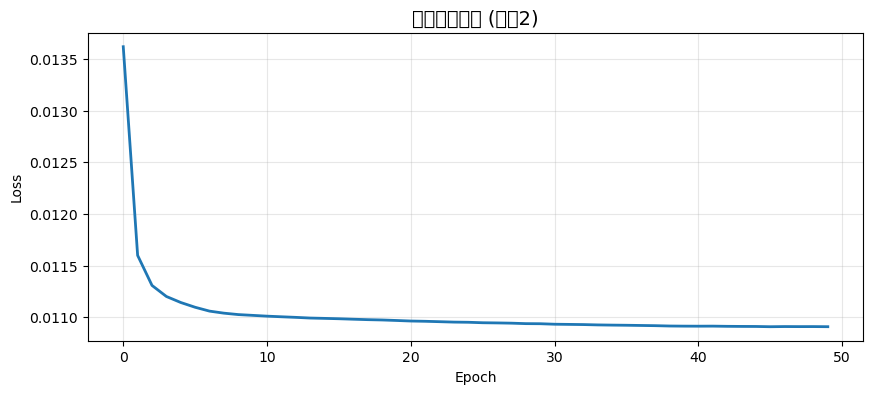


5. 生成损害代理图...

模式2: 直接相干性预测
不使用logit变换，直接预测相干性值
Score = (pre - post) / (pre + post)

处理 5,346,000 个像素
预震序列长度: 12


处理像素:   0%|          | 1/4455 [00:00<36:19,  2.04it/s]

已处理: 1,200 / 5,346,000 像素 (0.0%)


处理像素:   0%|          | 9/4455 [00:02<23:21,  3.17it/s]

已处理: 10,800 / 5,346,000 像素 (0.2%)


...

已处理: 5,329,200 / 5,346,000 像素 (99.7%)


处理像素: 100%|█████████▉| 4449/4455 [17:41<00:02,  2.78it/s]

已处理: 5,338,800 / 5,346,000 像素 (99.9%)


处理像素: 100%|██████████| 4455/4455 [17:42<00:00,  4.19it/s]


处理完成! 处理了 5,346,000 个有效像素
Score范围: [-0.6547, 0.7014]
Score均值: 0.0370
Score标准差: 0.1716

6. 可视化结果...
结果图已保存: results_mode2.png


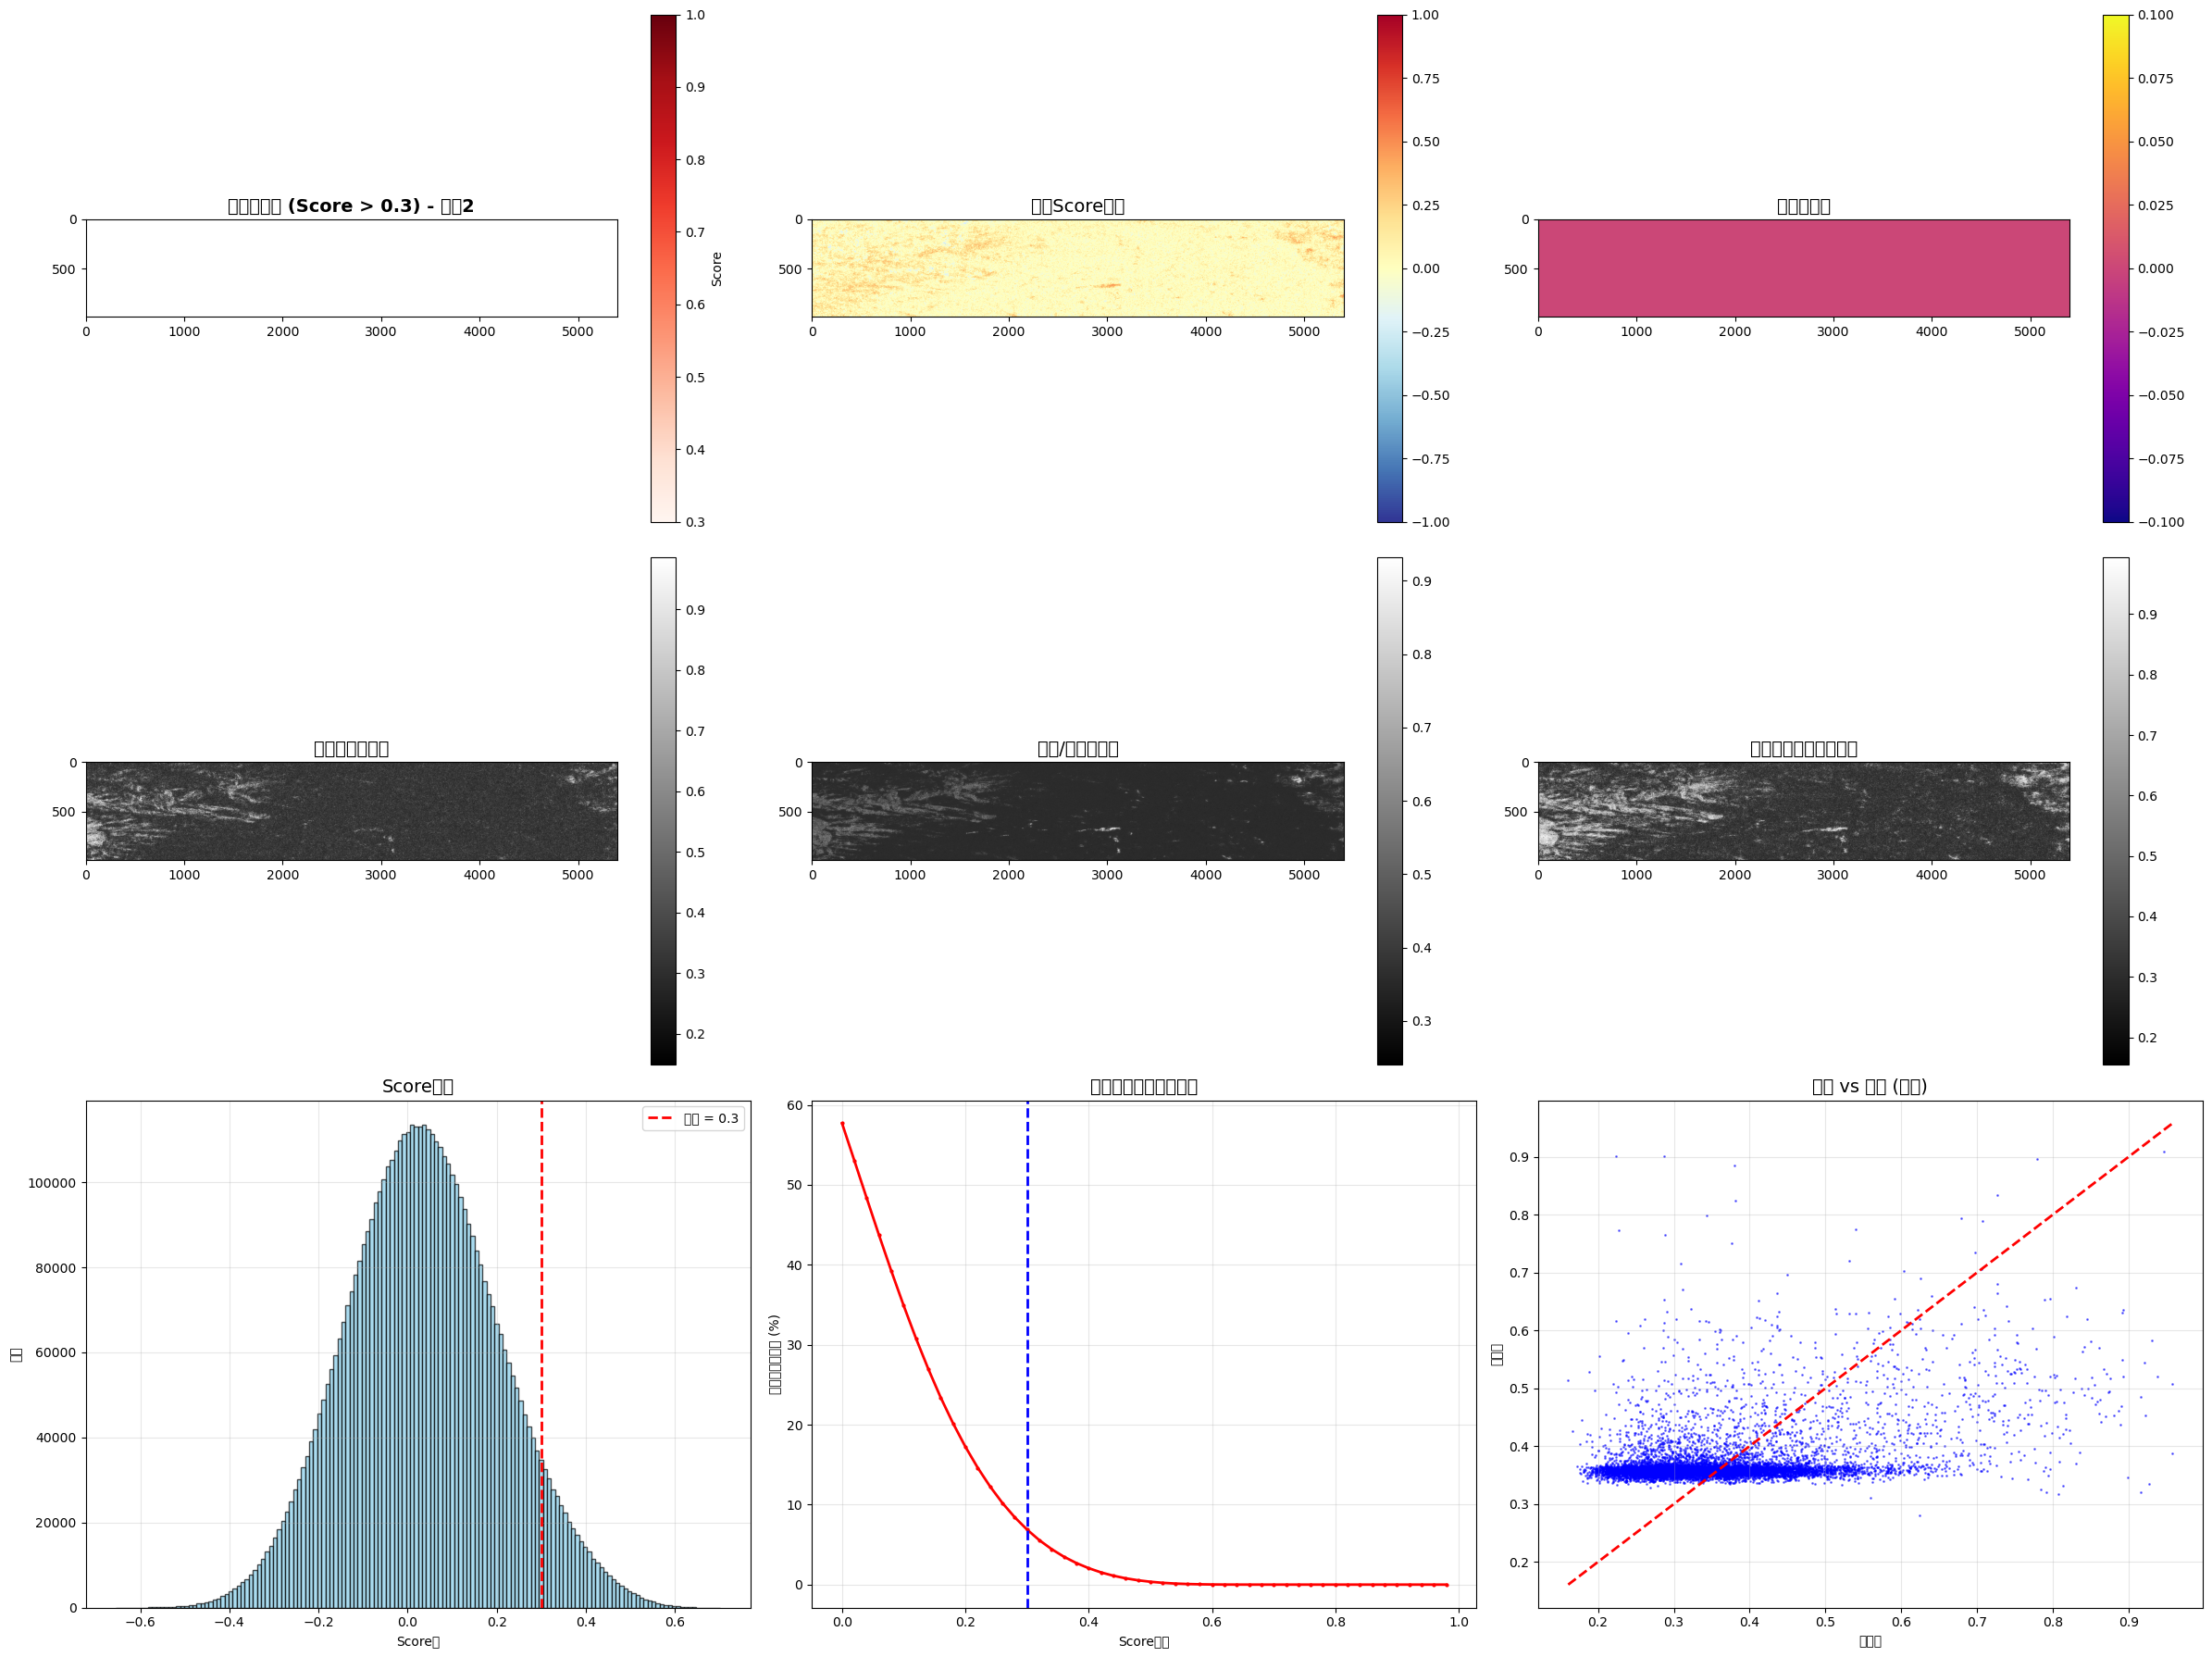


阿马特里切地震损害映射统计 (模式2)
总像素数: 5,346,000
有效像素数: 5,346,000 (100.0%)

Score统计:
  均值: 0.037
  标准差: 0.172
  中位数: 0.033
  范围: [-0.655, 0.701]

预测精度指标:
  均方误差 (MSE): 0.010649
  均方根误差 (RMSE): 0.103195
  平均绝对误差 (MAE): 0.079377
  皮尔逊相关系数: 0.3999

损害检测结果:
  Score > 0.1: 1,864,862 像素 (34.88%)
  Score > 0.2: 922,050 像素 (17.25%)
  Score > 0.3: 368,129 像素 (6.89%)
  Score > 0.4: 109,897 像素 (2.06%)
  Score > 0.5: 19,198 像素 (0.36%)
  Score > 0.6: 964 像素 (0.02%)

7. 保存结果...
结果已保存到: results_mode2
当前内存使用: 1.98 GB
GPU内存使用: 0.02 GB

🎉 模式2分析完成! 🎉


In [43]:
# ============================================================
# 运行分析
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("阿马特里切DPM-RNN扩展分析")
    print("="*70)
    print(f"\n选择的分析模式: {ANALYSIS_MODE}")
    
    if ANALYSIS_MODE == 0:
        print("描述: 原始RNN预测 (logit变换 + 概率预测)")
    elif ANALYSIS_MODE == 1:
        print("描述: 简单统计方法 (直接计算均值和标准差)")
    elif ANALYSIS_MODE == 2:
        print("描述: 直接相干性预测 (无logit变换 + 差分score)")
    
    print(f"\n数据路径: {DATA_PATH}")
    print(f"事件索引: {EVENT_INDEX}")
    print()
    
    # 运行分析
    result = main_analysis(
        mode=ANALYSIS_MODE,
        data_path=DATA_PATH,
        event_index=EVENT_INDEX
    )

In [44]:
# ============================================================
# 可选：运行所有三种模式进行比较
# ============================================================

def run_all_modes_comparison(data_path, event_index=12):
    """
    运行所有三种模式并进行比较
    """
    print("\n" + "="*70)
    print("运行所有模式进行比较")
    print("="*70)
    
    all_results = {}
    
    for mode in [0, 1, 2]:
        print(f"\n\n" + "#"*70)
        print(f"# 运行模式 {mode}")
        print("#"*70)
        
        result = main_analysis(
            mode=mode,
            data_path=data_path,
            event_index=event_index
        )
        
        if result is not None:
            all_results[mode] = result
    
    # 比较结果
    if len(all_results) > 1:
        print("\n\n" + "="*70)
        print("模式比较总结")
        print("="*70)
        
        for mode, (results, config) in all_results.items():
            z_scores = results['z_scores']
            valid_z = z_scores[np.isfinite(z_scores)]
            
            print(f"\n模式 {mode}:")
            print(f"  Score范围: [{np.min(valid_z):.4f}, {np.max(valid_z):.4f}]")
            print(f"  Score均值: {np.mean(valid_z):.4f}")
            print(f"  Score标准差: {np.std(valid_z):.4f}")
    
    return all_results

# 取消注释以下行来运行所有模式比较
# all_results = run_all_modes_comparison(DATA_PATH, EVENT_INDEX)

In [46]:
import numpy as np
import os
import subprocess
from mintpy.utils.writefile import write_isce_file

# 基础目录路径
base_dir = "/scratch/yangyanchen/amatrice2025/RNNbiye/"

# 获取所有_score.npy文件
score_files = [f for f in os.listdir(base_dir) 
              if f.endswith("_score.npy") and os.path.isfile(os.path.join(base_dir, f))]

# 经纬度文件路径
lat_file = os.path.join("/scratch/yangyanchen/amatrice2025/yunjun/", "lat_cropped.rdr")
lon_file = os.path.join("/scratch/yangyanchen/amatrice2025/yunjun/", "lon_cropped.rdr")

# 子集提取参数
subset_params = "-l 42.6 42.7 -L 13.2 13.4"

# 循环处理每个score文件
for score_file in score_files:
    try:
        # 1. 加载npy数据
        file_path = os.path.join(base_dir, score_file)
        print(f"处理文件: {score_file}")
        data = np.load(file_path)
        
        # 2. 创建输出文件名基础
        base_name = score_file.replace("_score.npy", "")
        
        # 3. 写入ISCE格式
        cor_file = os.path.join(base_dir, f"{base_name}.cor")
        write_isce_file(
            data=data,
            out_file=cor_file,
            file_type='isce_cor'
        )
        print(f"  ISCE文件已创建: {cor_file}")
        
        # 4. 地理编码
        geo_cor_file = os.path.join(base_dir, f"geo_{base_name}.cor")
        geocode_cmd = f"geocode.py {cor_file} --lat-file {lat_file} --lon-file {lon_file} --outdir {base_dir}"
        subprocess.run(geocode_cmd, shell=True, check=True)
        print(f"  地理编码完成: {geo_cor_file}")
        
        # 5. 子集提取
        subset_cor_file = os.path.join(base_dir, f"{base_name}final.cor")
        subset_cmd = f"subset.py {geo_cor_file} {subset_params} --output {subset_cor_file}"
        subprocess.run(subset_cmd, shell=True, check=True)
        print(f"  子集提取完成: {subset_cor_file}")
        
        # 6. 保存为GeoTIFF
        tif_file = os.path.join(base_dir, f"{base_name}final.tif")
        gdal_cmd = f"save_gdal.py {subset_cor_file} --output {tif_file}"
        subprocess.run(gdal_cmd, shell=True, check=True)
        print(f"  GeoTIFF已生成: {tif_file}")
        
        print(f"文件 {score_file} 处理完成!\n")
    
    except Exception as e:
        print(f"处理文件 {score_file} 时出错: {str(e)}")
        continue

print("所有文件处理完成!")

处理文件: z_scores_mode2_score.npy
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode2.cor
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode2.cor.xml
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode2.cor.vrt
  ISCE文件已创建: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode2.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/yunjun/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.72527662495149, 13.177307647518548, 13.439498382754891)
output file row / column number: (990, 5400)
[1/1] preparing geometry for dest_box: (0, 0, 5400, 990) 

/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode2final.tif
文件 z_scores_mode2_score.npy 处理完成!

处理文件: z_scores_mode1_score.npy
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode1.cor
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode1.cor.xml
write file: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode1.cor.vrt
  ISCE文件已创建: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode1.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/yunjun/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.72527662495149, 13.177307647518548, 13.4394

/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /scratch/yangyanchen/amatrice2025/RNNbiye/z_scores_mode1final.tif
文件 z_scores_mode1_score.npy 处理完成!

所有文件处理完成!


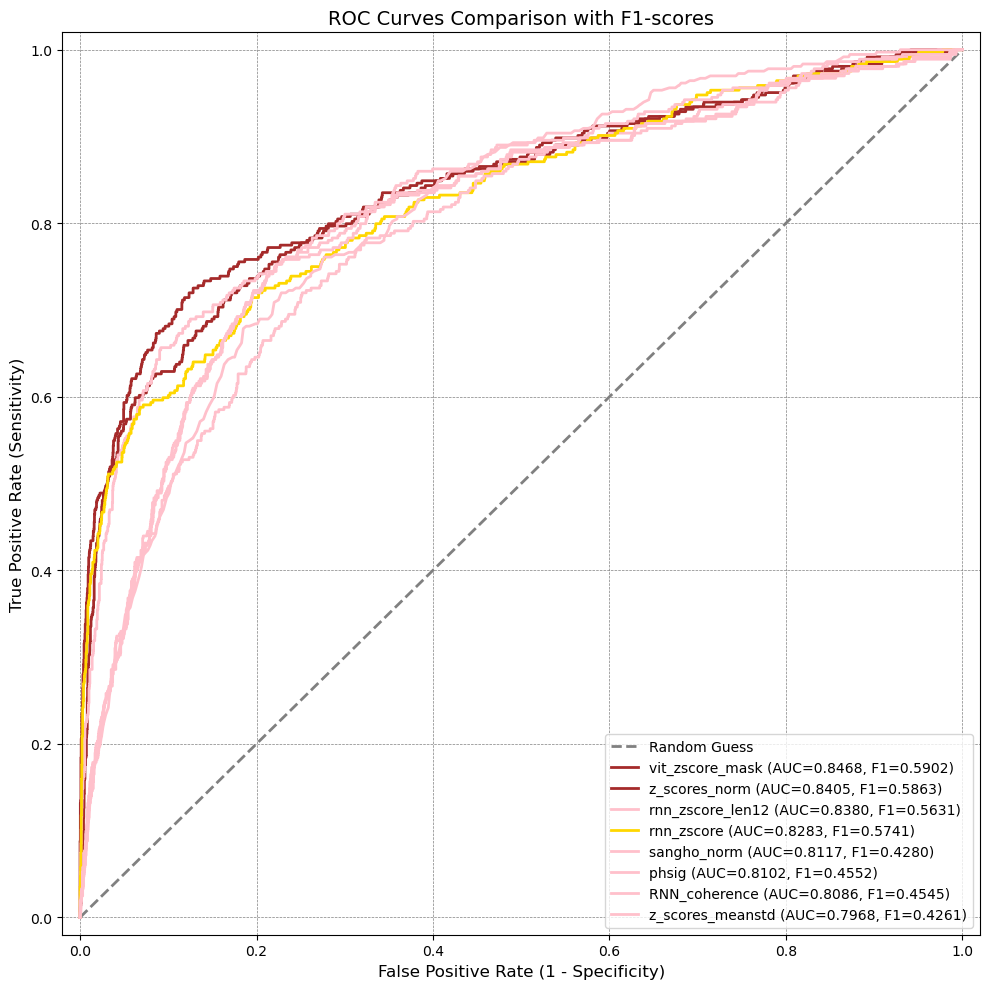


特征性能报告:
按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈值              虚警率(FPR)       
----------------------------------------------------------------------------------------------------
vit_zscore_mask 0.84680      0.59016         3.31149         0.04969        
z_scores_norm 0.84052      0.58626         0.58788         0.01896        
rnn_zscore_len12 0.83796      0.56313         2.51428         0.04282        
rnn_zscore   0.82829      0.57407         2.16880         0.03204        
sangho_norm  0.81168      0.42796         0.89737         0.11997        
phsig        0.81019      0.45522         0.34946         0.12063        
RNN_coherence 0.80863      0.45445         0.34531         0.12782        
z_scores_meanstd 0.79680      0.42612         1.65634         0.10559        

按F1-score排序:
----------------------------------------------------------

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

df = pd.read_csv("/scratch/yangyanchen/amatrice2025/RNNbiye/roc精度评价VIT.csv")  # 替换为你的文件路径

# 定义特征列表和颜色配置 decorrelation	TGRS_std	TGRS

features = [
    ("z_scores_norm", "brown"),
    ("vit_zscore_mask", "brown"),
    ("phsig", "pink"),
    ("sangho_norm", "pink"),
    ("rnn_zscore_len12", "pink"),
   ("RNN_coherence", "pink"),
   ("z_scores_meanstd", "pink"),
    ("rnn_zscore", "gold")
    
]

# 设置画布
plt.figure(figsize=(10, 10))

# 绘制参考线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess')

# 创建列表存储计算结果
roc_data = []
f1_results = []  # 存储F1-score结果

# 先计算所有特征的AUC值和F1-score
for feature, color in features:
    y_true = df['damaged']
    y_score = df[feature]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 找到最佳F1-score及其阈值
    best_f1 = 0
    best_threshold = 0
    best_fpr = 0
    best_f1_index = 0
    
    # 遍历所有阈值计算F1-score
    for i, threshold in enumerate(thresholds):
        # 使用当前阈值进行预测
        y_pred = (y_score >= threshold).astype(int)
        
        # 计算F1-score
        f1 = f1_score(y_true, y_pred)
        
        # 更新最佳F1-score
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_f1_index = i
    
    # 获取最佳阈值对应的虚警率(FPR)
    if best_f1_index < len(fpr):
        best_fpr = fpr[best_f1_index]
    else:
        # 如果索引越界，使用上一个可用的FPR值
        best_fpr = fpr[-1] if fpr.size > 0 else 0
    
    # 存储特征名、颜色、AUC值以及ROC曲线数据
    roc_data.append({
        'feature': feature,
        'color': color,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_fpr': best_fpr
    })
    
    # 存储F1结果用于后续输出
    f1_results.append({
        'feature': feature,
        'auc': roc_auc,
        'best_f1': best_f1,
        'threshold': best_threshold,
        'fpr': best_fpr
    })

# 按AUC值从高到低排序
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

# 按排序后的顺序绘制ROC曲线
for data in roc_data_sorted:
    plt.plot(data['fpr'], data['tpr'], color=data['color'], lw=2,
             label=f"{data['feature']} (AUC={data['auc']:.4f}, F1={data['best_f1']:.4f})")

# 图表装饰
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison with F1-scores', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('ROC_curves_with_F1_scores.png', dpi=300)
plt.show()

# 打印F1-score和虚警率结果
print("\n特征性能报告:")
print("按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

# 按AUC排序F1结果
f1_results_sorted = sorted(f1_results, key=lambda x: x['auc'], reverse=True)

for result in f1_results_sorted:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))

# 按F1-score排序
f1_results_sorted_by_f1 = sorted(f1_results, key=lambda x: x['best_f1'], reverse=True)

print("\n按F1-score排序:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_f1:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
# 按虚警率(FPR)排序（升序，即FPR越小越好）
f1_results_sorted_by_fpr = sorted(f1_results, key=lambda x: x['fpr'])

print("\n按虚警率(FPR)排序（从小到大）:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_fpr:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
